In [1]:
import json
from pathlib import Path

ANN = Path("../data/raw/football-players/train/_annotations.coco.json")

with open(ANN) as f:
    data = json.load(f)

print(type(data), data.keys())

<class 'dict'> dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])


In [2]:
print(data["images"][0])
print()
print(data["annotations"][0])
print()
print(data["categories"]) 

{'id': 0, 'license': 1, 'file_name': '42ba34_5_6_png.rf.0ba32a967bc26b71a97046f9635d9ef3.jpg', 'height': 576, 'width': 576, 'date_captured': '2025-08-01T20:49:11+00:00', 'extra': {'name': '42ba34_5_6.png'}}

{'id': 0, 'image_id': 0, 'category_id': 3, 'bbox': [395, 209, 4.5, 25], 'area': 112.5, 'segmentation': [], 'iscrowd': 0}

[{'id': 0, 'name': 'football-players-detection', 'supercategory': 'none'}, {'id': 1, 'name': 'ball', 'supercategory': 'football-players-detection'}, {'id': 2, 'name': 'goalkeeper', 'supercategory': 'football-players-detection'}, {'id': 3, 'name': 'player', 'supercategory': 'football-players-detection'}, {'id': 4, 'name': 'referee', 'supercategory': 'football-players-detection'}]


In [3]:
n = len(data["annotations"])
print(n)

print(data["annotations"][200])
print(data["categories"][1])

7133
{'id': 200, 'image_id': 8, 'category_id': 3, 'bbox': [456, 281, 8, 26], 'area': 208, 'segmentation': [], 'iscrowd': 0}
{'id': 1, 'name': 'ball', 'supercategory': 'football-players-detection'}


In [4]:
goalkeeper = 0
ball = 0
referee = 0
player = 0

for n in data["annotations"]:
    if n["category_id"] == 1:
        ball = ball + 1
    if n["category_id"] == 2:
        goalkeeper = goalkeeper + 1
    if n["category_id"] == 3:
        player = player + 1
    if n["category_id"] == 4:
        referee = referee + 1

print("ball: ", ball)
print("goalkeeper: ", goalkeeper)
print("player: ", player)
print("referee: ", referee)

total = ball + goalkeeper + player + referee

if total == len(data["annotations"]):
    print("La salida esta ajustada")
else:
    print("ERROR EN EL TOTAL DE ELEMENTOS")




ball:  258
goalkeeper:  230
player:  5955
referee:  690
La salida esta ajustada


In [5]:
# contar cuantas imagenes con 0, 1 y 2 porteros.

from collections import Counter

porteros_por_imagen = {}

for n in data["annotations"]:
    if n["category_id"] == 2:
        img = n["image_id"]
        porteros_por_imagen[img] = porteros_por_imagen.get(img, 0) + 1 

print(sum(porteros_por_imagen.values()))
print(len(porteros_por_imagen))

dist = Counter(porteros_por_imagen.values())
print(dist)


230
214
Counter({1: 198, 2: 16})


/home/juan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


42ba34_9_9_png.rf.606dc4e24b093022dc49cfff67374533.jpg


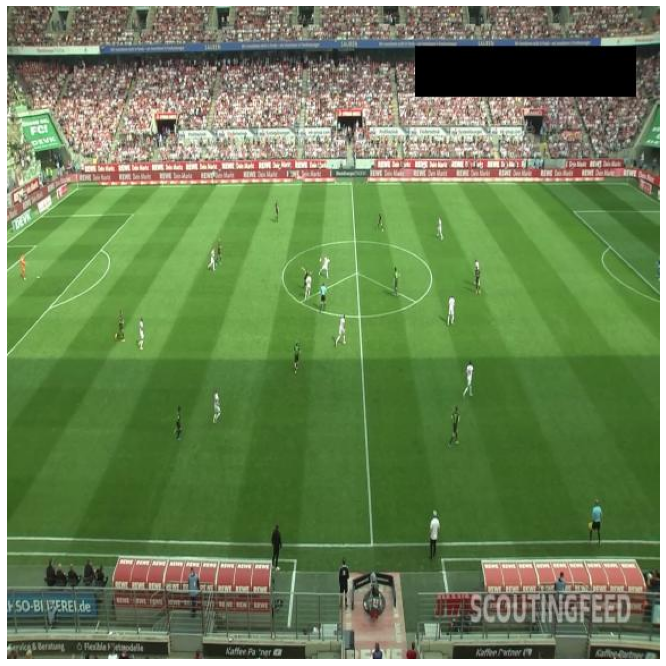

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

print(data["images"][65]["file_name"])

img = Image.open("../data/raw/football-players/train/42ba34_9_9_png.rf.606dc4e24b093022dc49cfff67374533.jpg")

plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis("off")
plt.savefig("../outputs/1.1-gt.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
id2name = {}
for c in data["categories"]:
    id2name[c["id"]] = c["name"]

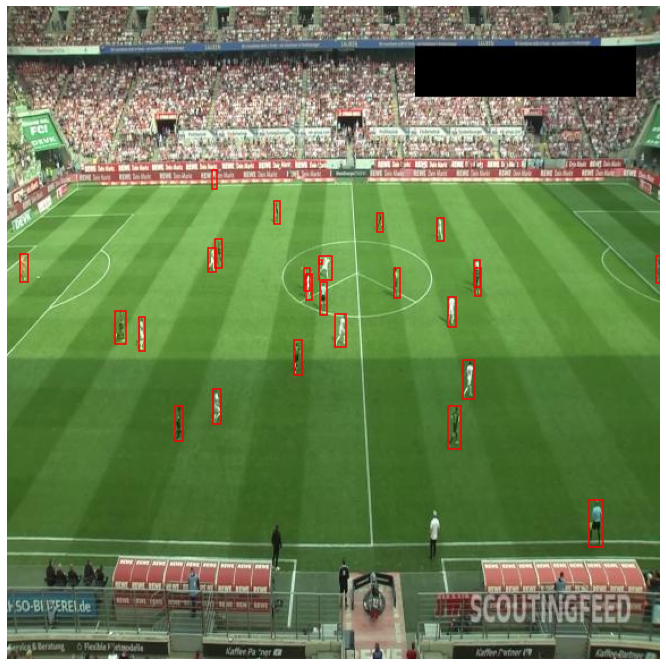

In [8]:
IMG_ID = 65

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(img)
ax.axis("off")

for n in data["annotations"]:
    if n["image_id"] == IMG_ID:
        x, y, w, h = n["bbox"]
        cat = n["category_id"]
        clase = id2name[cat]

        ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor="red", linewidth=1.5))

plt.savefig("../outputs/1.1-gt.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [10]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from torchvision.transforms.functional import to_tensor

IMG_ID = 65

img = Image.open("../data/raw/football-players/train/42ba34_9_9_png.rf.606dc4e24b093022dc49cfff67374533.jpg")
img_red_rectangles = Image.open("../outputs/1.1-gt.png")

x = to_tensor(img)

with torch.no_grad():
    pred = model([x])[0]

print(pred.keys())

img65_rectangulos = pred["boxes"].numpy()

print(img65_rectangulos)
print(len(img65_rectangulos))


dict_keys(['boxes', 'labels', 'scores'])
[[513.42926   435.07843   526.0748    472.40656  ]
 [410.5943    223.45511   418.9309    253.45316  ]
 [370.97272   446.75217   382.2266    487.35278  ]
 [232.42046   456.82166   243.00723   496.37427  ]
 [321.38278   560.9939    331.99017   576.       ]
 [261.37854   233.32451   268.94882   258.3028   ]
 [387.58856   255.22894   396.03003   282.8266   ]
 [401.73273   313.60718   412.5473    345.52112  ]
 [149.58202   108.646255  184.68968   126.65278  ]
 [351.58423   562.37463   363.21216   576.       ]
 [176.15677   211.16092   186.61366   234.80144  ]
 [181.06769   207.00383   190.59142   233.2123   ]
 [ 67.292244  489.59665    77.78656   510.66418  ]
 [340.37155   229.05107   346.0226    253.6379   ]
 [377.46725   186.37885   383.56995   205.41037  ]
 [260.7422    231.02434   267.68253   249.71063  ]
 [184.99657   108.180695  219.03107   120.41694  ]
 [ 77.04659   492.62213    86.3225    510.83667  ]
 [158.52104   494.07553   170.33679   531

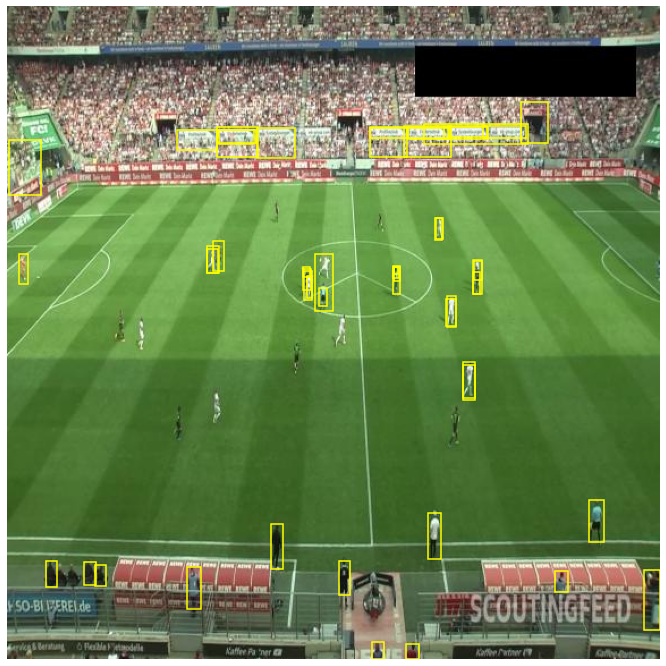

In [12]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(img)
ax.axis("off")

for n in img65_rectangulos:

    x1, y1, x2, y2 = n
    ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="yellow", linewidth=1.5))

plt.savefig("../outputs/1.2-gt.png", dpi=150, bbox_inches="tight")
plt.show()

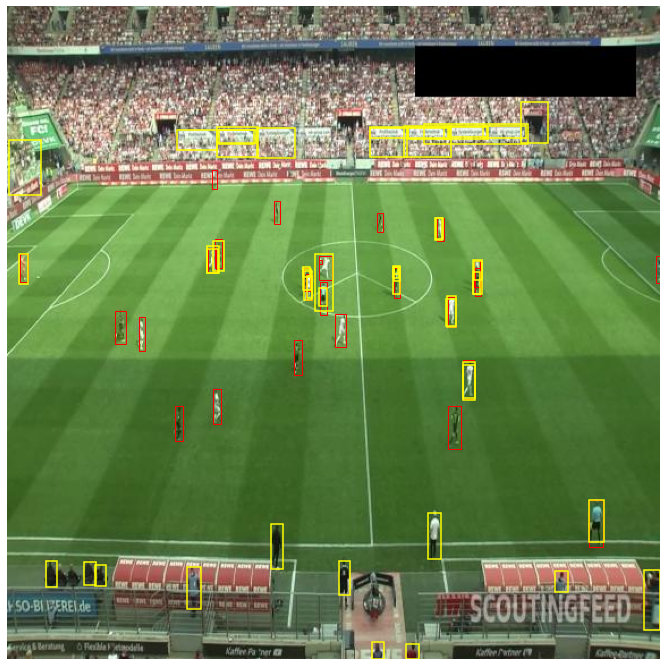

In [13]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(img)
ax.axis("off")

for n in data["annotations"]:                    # verdad, en rojo
    if n["image_id"] == IMG_ID:
        x, y, w, h = n["bbox"]
        ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor="red", linewidth=1))

for n in img65_rectangulos:

    x1, y1, x2, y2 = n
    ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="yellow", linewidth=1.5))

plt.savefig("../outputs/1.2-gt.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
boxes = []
for i, lab in enumerate(pred["labels"]):
    if int(lab) == 1:
        boxes.append(pred["boxes"][i])

print(boxes)

[tensor([513.4293, 435.0784, 526.0748, 472.4066]), tensor([410.5943, 223.4551, 418.9309, 253.4532]), tensor([370.9727, 446.7522, 382.2266, 487.3528]), tensor([232.4205, 456.8217, 243.0072, 496.3743]), tensor([321.3828, 560.9939, 331.9902, 576.0000]), tensor([261.3785, 233.3245, 268.9488, 258.3028]), tensor([387.5886, 255.2289, 396.0300, 282.8266]), tensor([401.7327, 313.6072, 412.5473, 345.5211]), tensor([351.5842, 562.3746, 363.2122, 576.0000]), tensor([176.1568, 211.1609, 186.6137, 234.8014]), tensor([181.0677, 207.0038, 190.5914, 233.2123]), tensor([ 67.2922, 489.5966,  77.7866, 510.6642]), tensor([340.3716, 229.0511, 346.0226, 253.6379]), tensor([377.4673, 186.3788, 383.5699, 205.4104]), tensor([260.7422, 231.0243, 267.6825, 249.7106]), tensor([ 77.0466, 492.6221,  86.3225, 510.8367]), tensor([158.5210, 494.0755, 170.3368, 531.2762]), tensor([339.8702, 229.3048, 345.1216, 238.9295]), tensor([ 33.5173, 489.3628,  43.5843, 511.8732]), tensor([453.2055,  83.7213, 477.0913, 120.1436]),

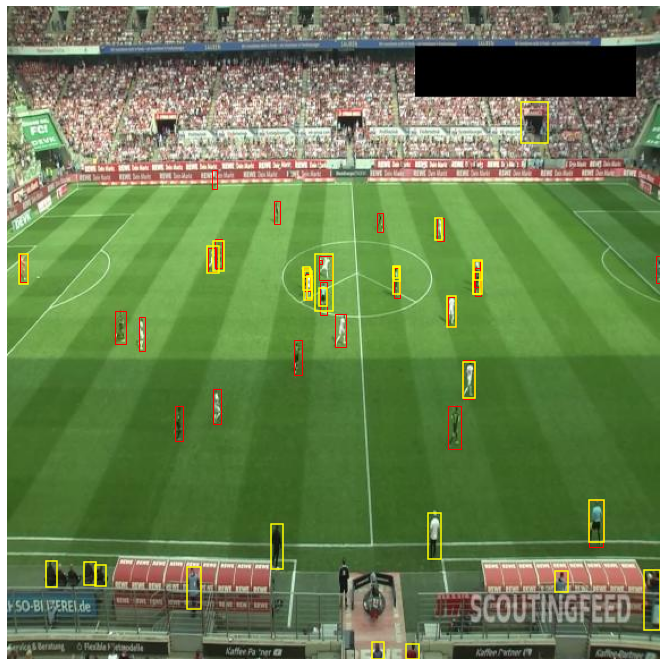

In [15]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(img)
ax.axis("off")

for n in data["annotations"]:                    # verdad, en rojo
    if n["image_id"] == IMG_ID:
        x, y, w, h = n["bbox"]
        ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor="red", linewidth=1))

for n in boxes:

    x1, y1, x2, y2 = n
    ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="yellow", linewidth=1.5))

plt.savefig("../outputs/1.2-gt.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

from src.CocoDataset import CocoDataset

ds = CocoDataset("../data/raw/football-players/train")
print(ds.data.keys())

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])


In [17]:
print(data["annotations"])

[{'id': 0, 'image_id': 0, 'category_id': 3, 'bbox': [395, 209, 4.5, 25], 'area': 112.5, 'segmentation': [], 'iscrowd': 0}, {'id': 1, 'image_id': 0, 'category_id': 3, 'bbox': [423, 187, 5.5, 24.5], 'area': 134.75, 'segmentation': [], 'iscrowd': 0}, {'id': 2, 'image_id': 0, 'category_id': 3, 'bbox': [485, 228, 6, 27.5], 'area': 165, 'segmentation': [], 'iscrowd': 0}, {'id': 3, 'image_id': 0, 'category_id': 3, 'bbox': [389, 172, 4.5, 22.5], 'area': 101.25, 'segmentation': [], 'iscrowd': 0}, {'id': 4, 'image_id': 0, 'category_id': 3, 'bbox': [348, 163, 5.5, 23.5], 'area': 129.25, 'segmentation': [], 'iscrowd': 0}, {'id': 5, 'image_id': 0, 'category_id': 3, 'bbox': [477, 231, 11, 29], 'area': 319, 'segmentation': [], 'iscrowd': 0}, {'id': 6, 'image_id': 0, 'category_id': 3, 'bbox': [284, 171, 5, 24], 'area': 120, 'segmentation': [], 'iscrowd': 0}, {'id': 7, 'image_id': 0, 'category_id': 3, 'bbox': [212, 185, 8.5, 27], 'area': 229.5, 'segmentation': [], 'iscrowd': 0}, {'id': 8, 'image_id': 0

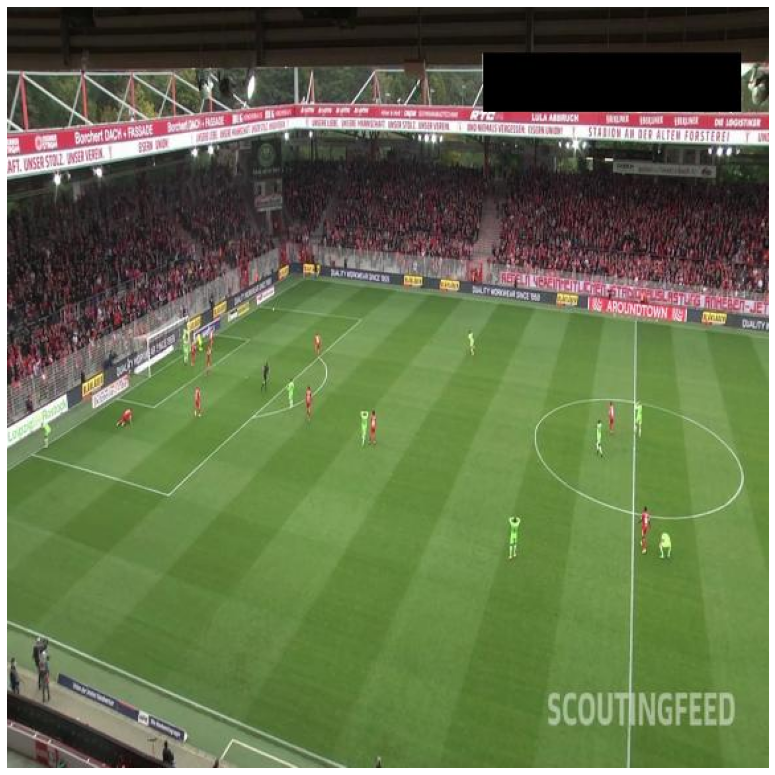

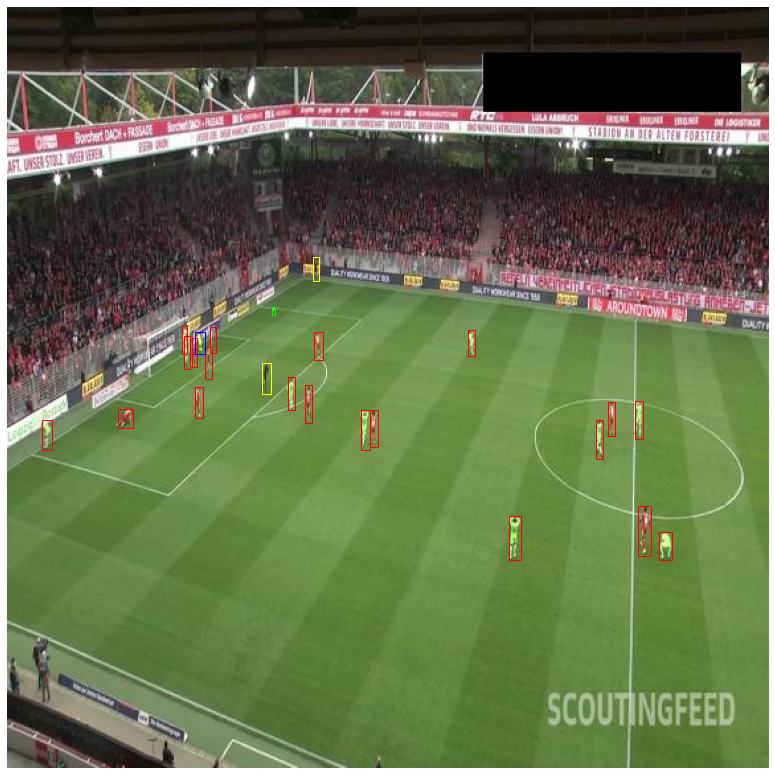

In [18]:
from src.viz import dibujarCajas

fig, ax = plt.subplots(figsize=(14, 14))
ax.imshow(ds.imagen(20))
ax.axis("off")
plt.show()

fig, ax = plt.subplots(figsize=(14, 14))
ax.imshow(ds.imagen(20))
ax.axis("off")
dibujarCajas(ax, ds.cajas(20))
plt.show()

In [19]:
from src.metricas import emparejar

img = ds.imagen(20)
cajasDataset = ds.cajas(20)

x = to_tensor(img)

with torch.no_grad():
    pred = model([x])[0]

keep = pred["labels"] == int(1)
predichas = pred["boxes"][keep].tolist()

PERSONAS = {"player", "goalkeeper", "referee"}

verdad = [c for c, k in ds.cajas(20) if k in PERSONAS]

parejas, perdidos, falsos = emparejar(verdad, predichas)

print(len(verdad), "reales |", len(predichas), "predichas |", len(parejas), "aciertos")
print("recall   ", len(parejas) / len(verdad))
print("precision", len(parejas) / len(predichas))


23 reales | 24 predichas | 13 aciertos
recall    0.5652173913043478
precision 0.5416666666666666


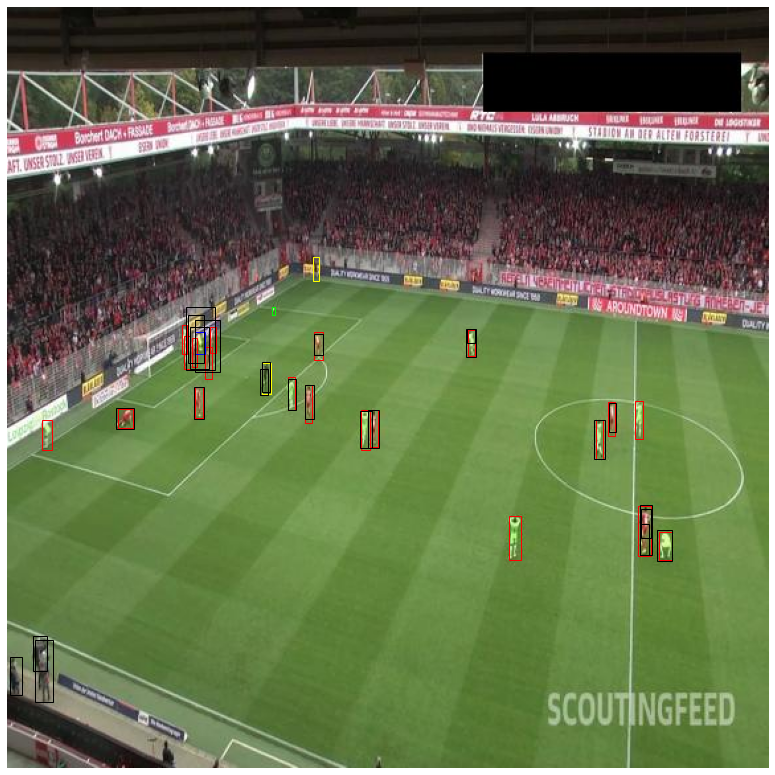

In [20]:
fig, ax = plt.subplots(figsize=(14, 14))
ax.imshow(ds.imagen(20))
ax.axis("off")
dibujarCajas(ax, ds.cajas(20))
dibujarCajas(ax, [(c, "pred") for c in predichas], colores={"pred": "black"})
plt.show()

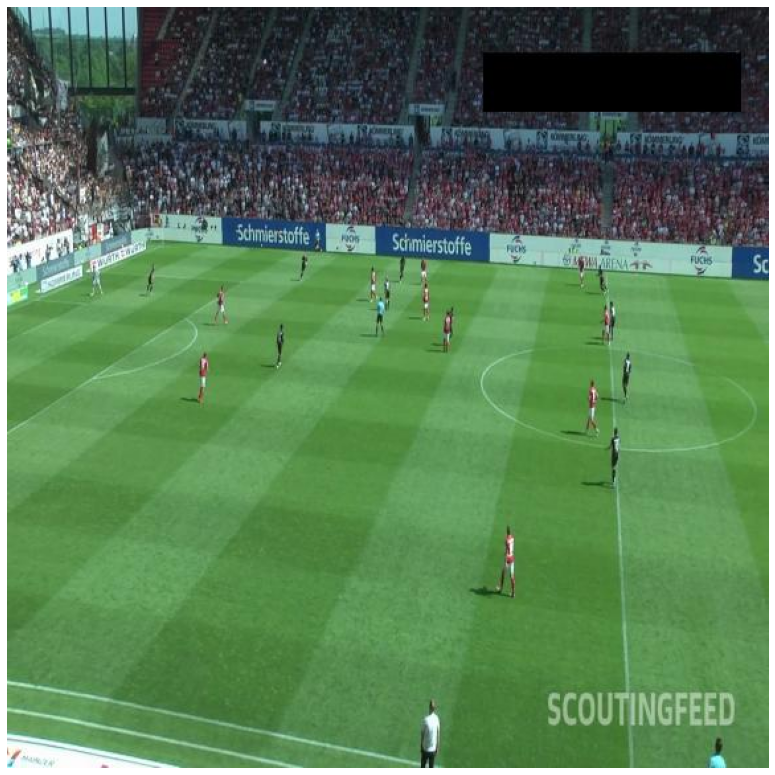

{'id': 1, 'image_id': 0, 'category_id': 3, 'bbox': [423, 187, 5.5, 24.5], 'area': 134.75, 'segmentation': [], 'iscrowd': 0}


In [21]:
imagen = ds.imagen(5)

fig, ax = plt.subplots(figsize=(14, 14))
ax.imshow(imagen)
ax.axis("off")
plt.show()

print(ds.data["annotations"][1])

In [22]:
from src.viz import dibujarAllImagenes

ds = CocoDataset("../data/raw/football-players/train")

dibujarAllImagenes(ds, "../outputs/datasetPainted")

In [23]:
resultados = {}
for n, i in enumerate(sorted(ds.id2fichero), 1):
    x = to_tensor(ds.imagen(i))
    with torch.no_grad():
        p = model([x])[0]
    keep = p["labels"] == int(1)
    resultados[i] = {
        "boxes":  p["boxes"][keep].tolist(),
        "scores": p["scores"][keep].tolist(),
    }
    if n % 25 == 0:
        print(n, "/", len(ds.id2fichero))

import json
with open("../outputs/predicciones_train.json", "w") as f:
    json.dump(resultados, f)

KeyboardInterrupt: 

In [ ]:
with open("../outputs/predicciones_train.json") as f:
    preds = json.load(f)
dibujarAllImagenes(ds, "../outputs/superpuestas", predicciones=preds)

In [ ]:
from src.metricas import evaluar

for s in (0.05, 0.3, 0.5, 0.7, 0.9):
    filtradas = {
        k: {"boxes": [b for b, sc in zip(v["boxes"], v["scores"]) if sc >= s]}
        for k, v in preds.items()
    }
    r, p = evaluar(ds, filtradas)
    print(f"score {s}  recall {r:.3f}  precision {p:.3f}")

score 0.05  recall 0.783  precision 0.380
score 0.3  recall 0.700  precision 0.643
score 0.5  recall 0.631  precision 0.738
score 0.7  recall 0.529  precision 0.808
score 0.9  recall 0.301  precision 0.855


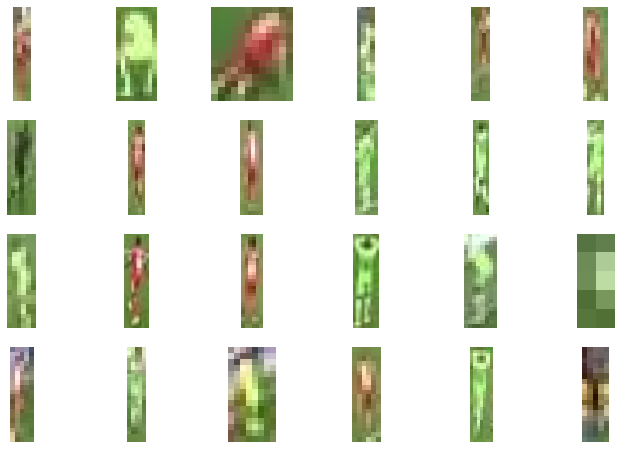

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")


from src.CocoDataset import CocoDataset

ds = CocoDataset("../data/raw/football-players/train")

cajas = [c for c, k in ds.cajas(20)]
img = ds.imagen(20)

fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for ax, (x1, y1, x2, y2) in zip(axes.flat, cajas):
    ax.imshow(img.crop((x1, y1, x2, y2)))
    ax.axis("off")
plt.show()